In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [5]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [6]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [7]:
mnist.keys()  # extra code – we only use data and target in this notebook

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [8]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [9]:
X.shape

(70000, 784)

In [10]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [11]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[9]
#plot_digit(some_digit)
#save_fig("some_digit_plot")  # extra code
#plt.show()

In [12]:
y[9]

'4'

In [13]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [14]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, classification_report

y_train_i = y_train.astype(np.int64)
y_test_i  = y_test.astype(np.int64)

sgd_clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(random_state=42)
)

sgd_clf.fit(X_train, y_train_i)

y_pred = sgd_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test_i, y_pred))
print(classification_report(y_test_i, y_pred))

Accuracy: 0.8933
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       980
           1       0.98      0.95      0.97      1135
           2       0.94      0.86      0.90      1032
           3       0.92      0.87      0.89      1010
           4       0.94      0.89      0.92       982
           5       0.91      0.80      0.85       892
           6       0.94      0.92      0.93       958
           7       0.95      0.90      0.92      1028
           8       0.61      0.93      0.73       974
           9       0.93      0.84      0.88      1009

    accuracy                           0.89     10000
   macro avg       0.91      0.89      0.90     10000
weighted avg       0.91      0.89      0.90     10000



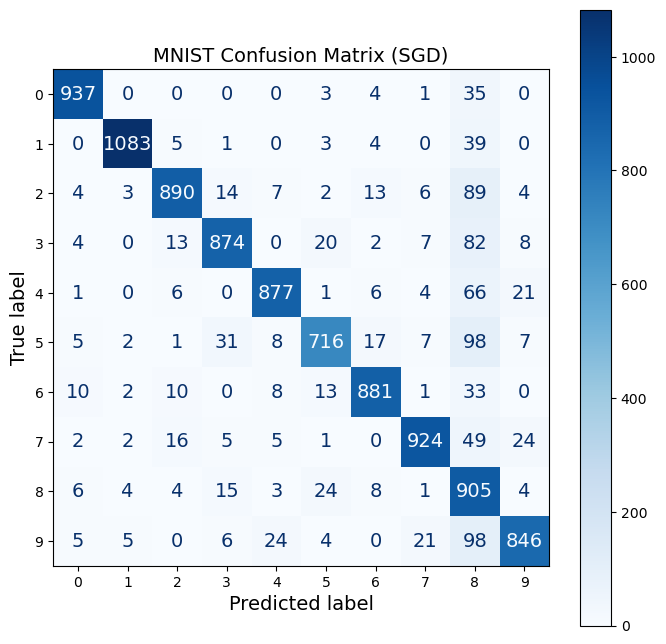

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_i, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("MNIST Confusion Matrix (SGD)")
plt.show()


We can see from the confuion matrix that the multiclass classification for predicting 8 has errors

In [16]:
# --- Data augmentation: shift images by 1 pixel in 4 directions ---
import numpy as np

def shift_image(flat_img: np.ndarray, dx: int, dy: int) -> np.ndarray:
    """Shift ONE flattened MNIST image by (dx, dy) pixels with zero padding.
    dx: +1 right, -1 left, 0 none
    dy: +1 down,  -1 up,   0 none
    Returns a flattened (784,) uint8 array.
    """
    img = flat_img.reshape(28, 28)
    shifted = np.zeros_like(img)

    # Source slice
    x_from = max(0, -dx)
    x_to   = 28 - max(0, dx)
    y_from = max(0, -dy)
    y_to   = 28 - max(0, dy)

    # Destination slice
    x_dst_from = max(0, dx)
    x_dst_to   = x_dst_from + (x_to - x_from)
    y_dst_from = max(0, dy)
    y_dst_to   = y_dst_from + (y_to - y_from)

    shifted[y_dst_from:y_dst_to, x_dst_from:x_dst_to] = img[y_from:y_to, x_from:x_to]
    return shifted.reshape(784)

def shift_batch(X_flat_u8: np.ndarray, direction: str) -> np.ndarray:
    """Vectorized shift for a batch of flattened MNIST images (N, 784) by 1 pixel."""
    imgs = X_flat_u8.reshape(-1, 28, 28)
    shifted = np.zeros_like(imgs)

    if direction == "left":
        shifted[:, :, :-1] = imgs[:, :, 1:]
    elif direction == "right":
        shifted[:, :, 1:] = imgs[:, :, :-1]
    elif direction == "up":
        shifted[:, :-1, :] = imgs[:, 1:, :]
    elif direction == "down":
        shifted[:, 1:, :] = imgs[:, :-1, :]
    else:
        raise ValueError("direction must be one of: left, right, up, down")

    return shifted.reshape(-1, 784)

# Convert to compact dtype first (OpenML gives floats; values are 0..255)
X_train_u8 = np.asarray(X_train, dtype=np.uint8)
X_test_u8  = np.asarray(X_test, dtype=np.uint8)

y_train_i = y_train.astype(np.int64)
y_test_i  = y_test.astype(np.int64)

# Create 4 shifted copies (vectorized)
X_left  = shift_batch(X_train_u8, "left")
X_right = shift_batch(X_train_u8, "right")
X_up    = shift_batch(X_train_u8, "up")
X_down  = shift_batch(X_train_u8, "down")

# Expanded training set (original + 4 shifts)
X_train_aug = np.concatenate([X_train_u8, X_left, X_right, X_up, X_down], axis=0)
y_train_aug = np.tile(y_train_i, 5)

X_train_aug.shape, y_train_aug.shape


((300000, 784), (300000,))

In [17]:
# --- Train (best) model(s) on augmented data and evaluate on the original test set ---
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

# SGD is fast and scales well with the 5x larger dataset
best_sgd = make_pipeline(
    StandardScaler(),
    SGDClassifier(random_state=42, loss="log_loss", alpha=1e-4, max_iter=1000, tol=1e-3)
)

best_sgd.fit(X_train_aug, y_train_aug)

y_pred_aug = best_sgd.predict(X_test_u8)

print("Augmented-training Accuracy:", accuracy_score(y_test_i, y_pred_aug))
print(classification_report(y_test_i, y_pred_aug))


Augmented-training Accuracy: 0.8952
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       980
           1       0.97      0.98      0.97      1135
           2       0.97      0.86      0.91      1032
           3       0.93      0.87      0.90      1010
           4       0.91      0.91      0.91       982
           5       0.85      0.85      0.85       892
           6       0.96      0.90      0.93       958
           7       0.95      0.89      0.92      1028
           8       0.65      0.93      0.76       974
           9       0.93      0.80      0.86      1009

    accuracy                           0.90     10000
   macro avg       0.91      0.89      0.90     10000
weighted avg       0.91      0.90      0.90     10000



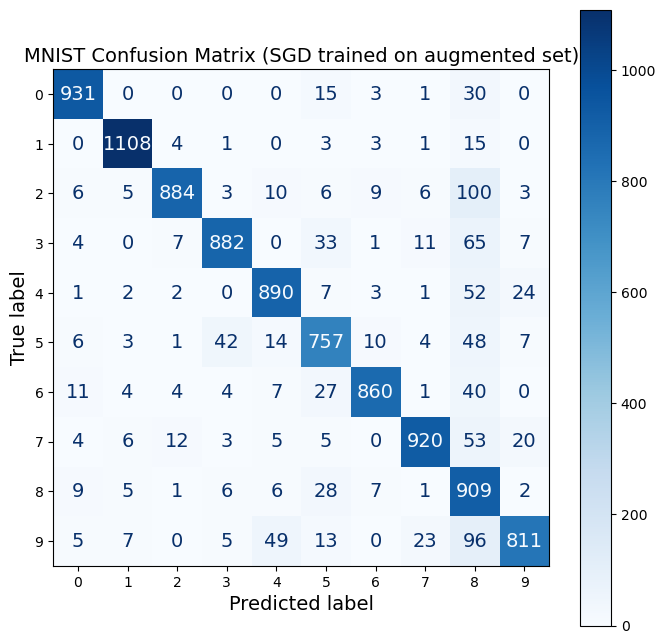

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_aug = confusion_matrix(y_test_i, y_pred_aug)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_aug)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("MNIST Confusion Matrix (SGD trained on augmented set)")
plt.show()
